## 1.Import Library

In [247]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from wordcloud import WordCloud
from collections import Counter
import re

## 2. Read dataset 

In [248]:
df_raw = pd.read_csv('../data/data_processed/trainprocessed.csv')

In [249]:
df_raw.columns

Index(['comment', 'n_star', 'date_time', 'label', 'positive_count',
       'neutral_count', 'negative_count'],
      dtype='object')

In [250]:
display(df_raw.head(5))

,comment,n_star,date_time,label,positive_count,neutral_count,negative_count
0,pin kém còn miễn chê mua 832019 tình_trạng pin...,5,14/09/2019,Neutral,1,0,1
1,sao gọi điện_thoại màn_hình chấm nhỏ nháy gần ...,3,17/08/2020,Negative,0,0,1
2,mọi người cập_nhật phần_mềm nó bớt tốn pin mìn...,3,29/02/2020,Neutral,0,2,1
3,mới mua sài 1 tháng thấy pin trâu sài bao mượt...,5,4/6/2020,Positive,2,0,1
4,xài tốt mượt pin trâu bạn độ sáng đủ nhân_viên...,5,20/06/2019,Positive,3,2,0


In [251]:
df_raw.shape

(8898, 7)

## 3. Exploratory Data Analysis

### 3.1. The density of n_start

In [252]:
df_raw['n_star'].value_counts()

n_star
5    4185
4    1454
1    1443
3    1168
2     648
Name: count, dtype: int64

C:\Users\hghaa\AppData\Local\Temp\ipykernel_27204\3980497846.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_raw, x='n_star', palette='viridis')


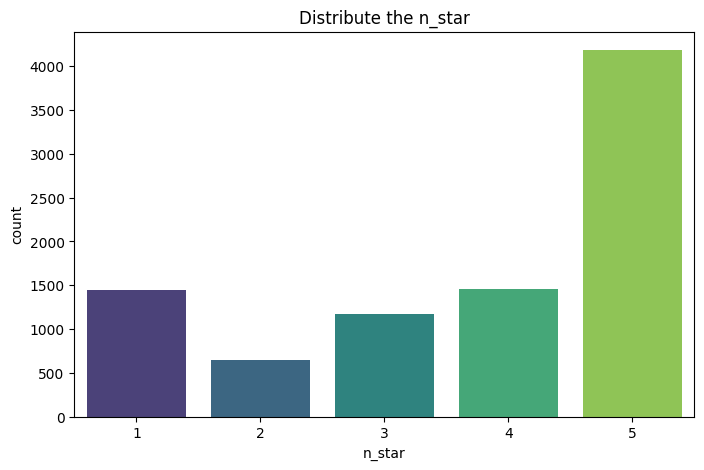

In [253]:
# 5. Phân phối số sao (n_star)
plt.figure(figsize=(8, 5))
sns.countplot(data=df_raw, x='n_star', palette='viridis')
plt.title('Distribute the n_star')
plt.show()

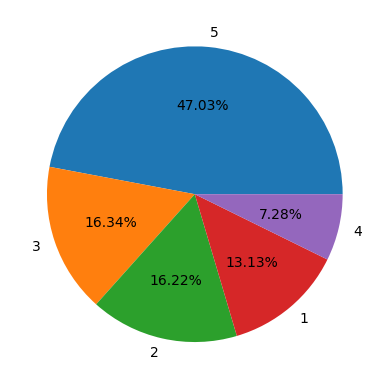

In [254]:
plt.pie(df_raw['n_star'].value_counts(), labels=df_raw['n_star'].unique().tolist(), autopct='%.2f%%')
plt.show()

> Mostly concentrated in 5 stars (47.03%)

### 3.2. The density of label

In [255]:
df_raw['label'].value_counts()

label
Positive    4592
Negative    3378
Neutral      928
Name: count, dtype: int64

C:\Users\hghaa\AppData\Local\Temp\ipykernel_27204\2843270296.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_raw, x='label', palette='viridis')


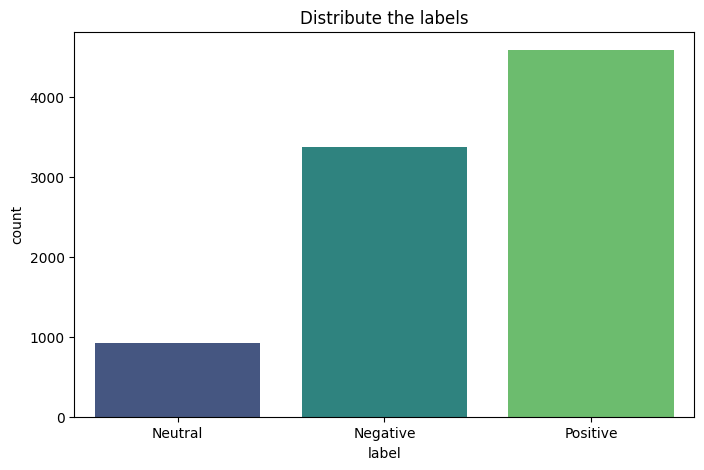

In [256]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df_raw, x='label', palette='viridis')
plt.title('Distribute the labels')
plt.show()

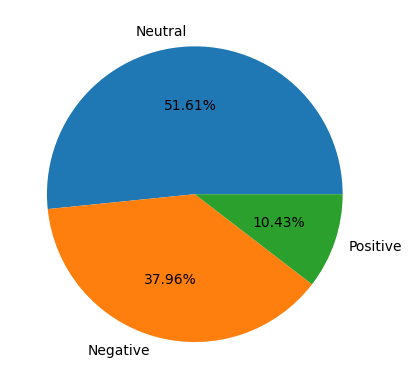

In [257]:
plt.pie(df_raw['label'].value_counts(), labels=df_raw['label'].unique().tolist(), autopct='%.2f%%')
plt.show()

> Most comments are positive (51.61%)

### 3.3. The correlation between positive, negative, neutral and n_star

In [258]:
correlation_matrix = df_raw[['positive_count', 'negative_count', 'neutral_count', 'n_star']].corr()
print(correlation_matrix)

                positive_count  negative_count  neutral_count    n_star
positive_count        1.000000       -0.569783       0.040787  0.649681
negative_count       -0.569783        1.000000      -0.153642 -0.688968
neutral_count         0.040787       -0.153642       1.000000  0.140701
n_star                0.649681       -0.688968       0.140701  1.000000


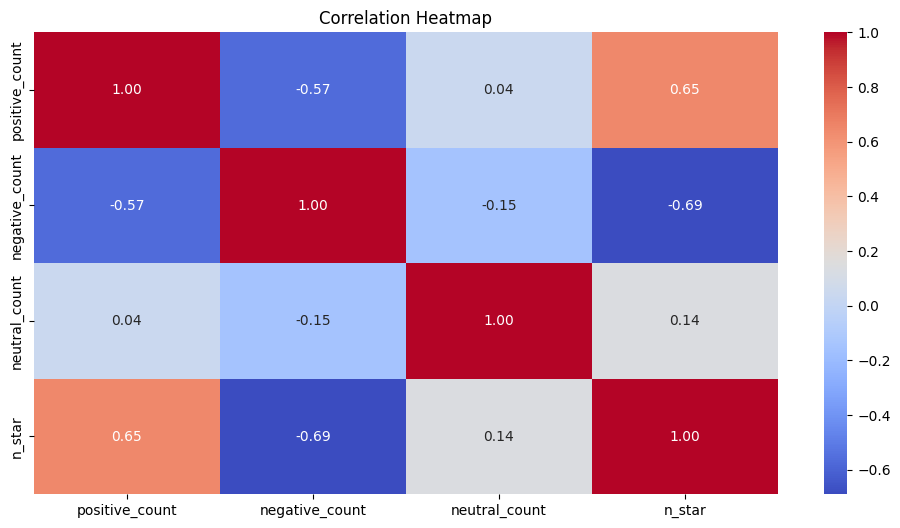

In [259]:
plt.figure(figsize=(12, 6))
sns.heatmap(df_raw[['positive_count', 'negative_count', 'neutral_count', 'n_star']].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

> Based on the above analysis, it can be concluded that:

* Positive and N_star have the strongest positive correlation.
* Negative and N_star have the strongest negative relationship.
* Positive and negative have strong negative correlation.
* Neutral and n_star, positive and neutral, negative and neutral have an important relationship.

### 3.4. Word Cloud of comments

In [260]:
text = " ".join(comment for comment in df_raw['comment'])

In [261]:
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

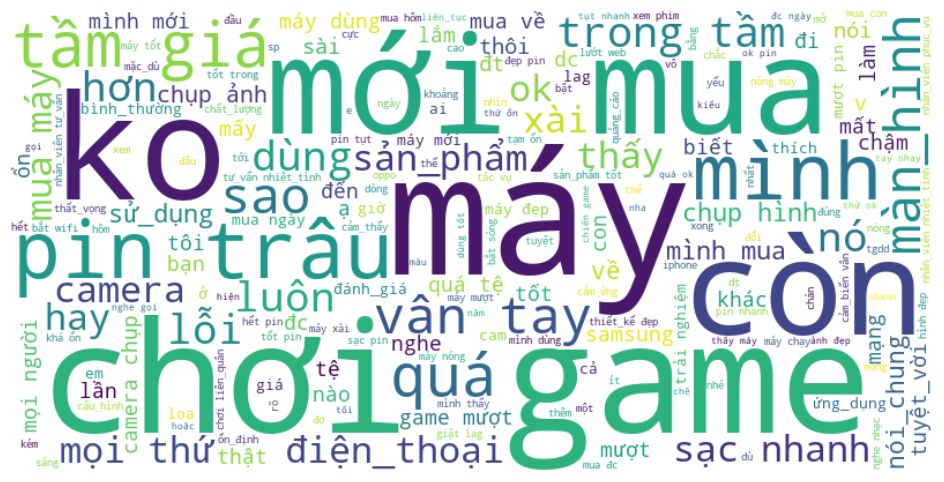

In [262]:
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

> The keywords are displayed with different sizes, the bigger the size, the more the keywords are mentioned.

### 3.5. Distribution date of comments

In [263]:
df_raw['date_time'] = pd.to_datetime(df_raw['date_time'])

C:\Users\hghaa\AppData\Local\Temp\ipykernel_27204\272887500.py:1: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df_raw['date_time'] = pd.to_datetime(df_raw['date_time'])


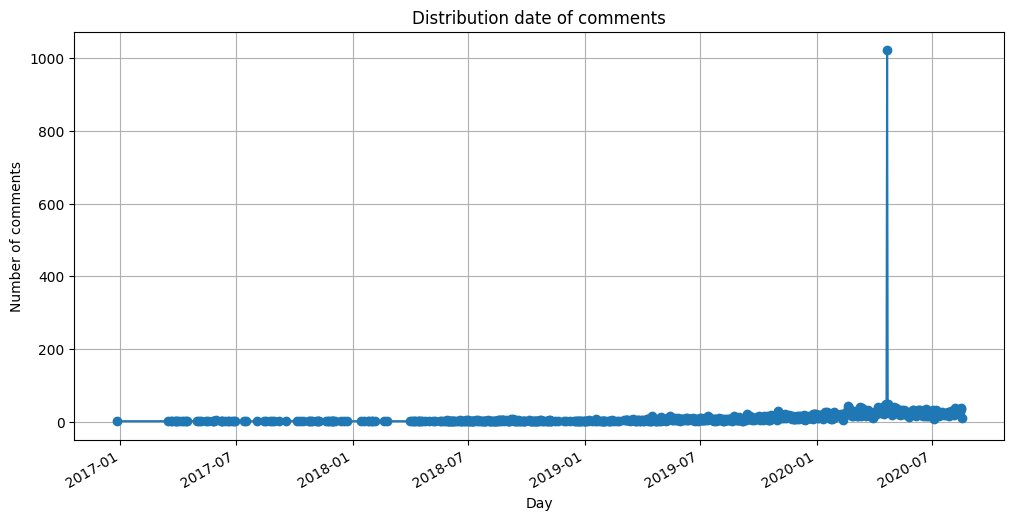

In [264]:
plt.figure(figsize=(12, 6))
df_raw['date_time'].value_counts().sort_index().plot(kind='line', marker='o')
plt.title('Distribution date of comments')
plt.xlabel('Day')
plt.ylabel('Number of comments')
plt.grid(True)
plt.show()

### 3.6. Distribution of stars by labels

C:\Users\hghaa\AppData\Local\Temp\ipykernel_27204\343761309.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_raw, x='label', y='n_star', palette='viridis')


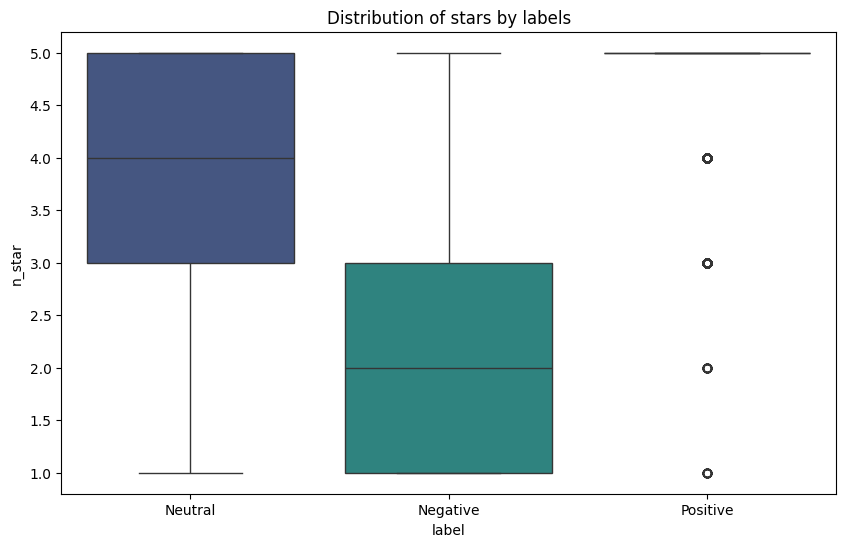

In [265]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_raw, x='label', y='n_star', palette='viridis')
plt.title('Distribution of stars by labels')
plt.show()

### 3.7. Frequency charts of words in comments

In [266]:
all_comments = " ".join(comment.lower() for comment in df_raw['comment'])

In [267]:
words = re.findall(r'\b\w+\b', all_comments)
word_counts = Counter(words)
common_words = word_counts.most_common(20)  
common_words_df = pd.DataFrame(common_words, columns=['word', 'count'])

C:\Users\hghaa\AppData\Local\Temp\ipykernel_27204\1499361142.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=common_words_df, x='count', y='word', palette='viridis')


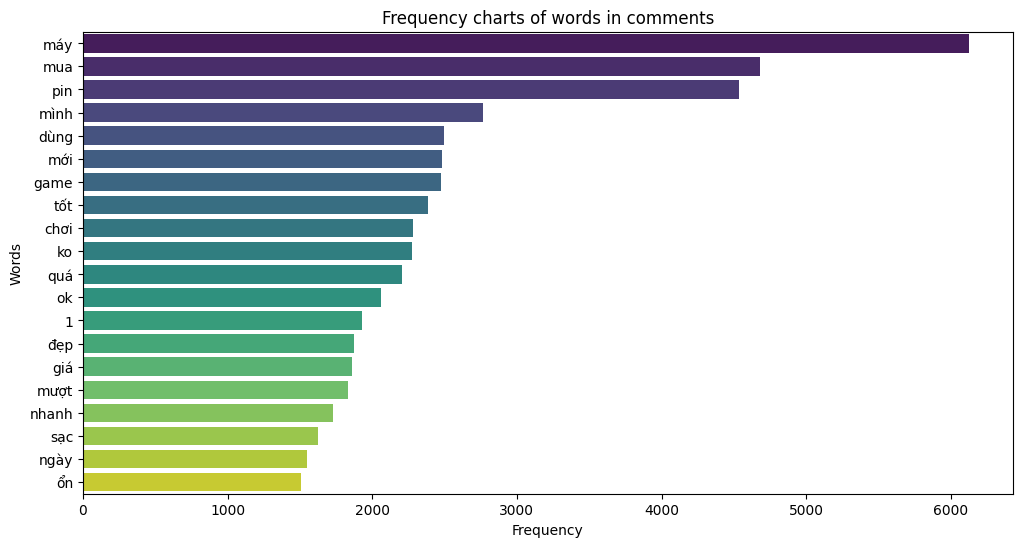

In [268]:
plt.figure(figsize=(12, 6))
sns.barplot(data=common_words_df, x='count', y='word', palette='viridis')
plt.title('Frequency charts of words in comments')
plt.xlabel('Frequency')
plt.ylabel('Words')
plt.show()

### 3.8. Distribution of stars over time

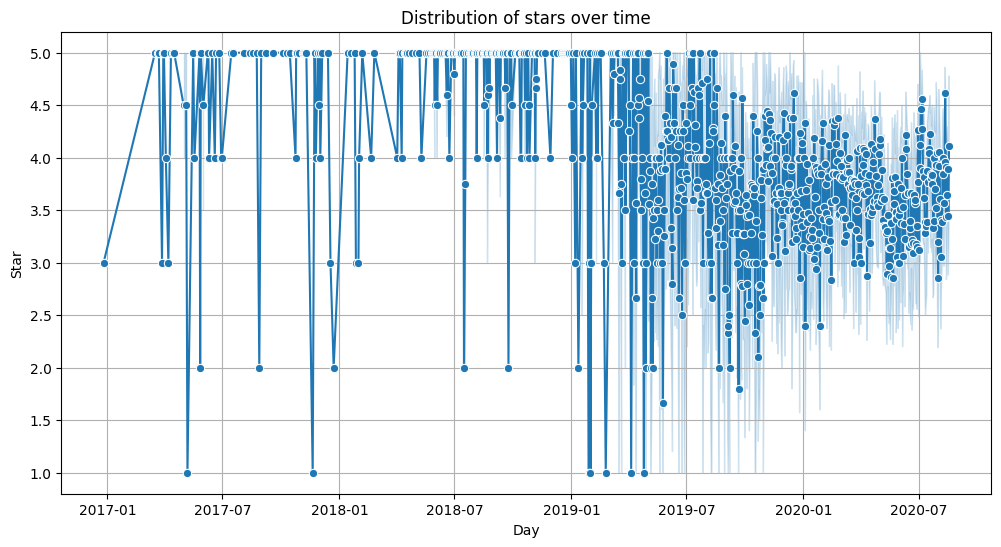

In [269]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_raw, x='date_time', y='n_star', marker='o')
plt.title('Distribution of stars over time')
plt.xlabel('Day')
plt.ylabel('Star')
plt.grid(True)
plt.show()

### 3.9. Discover words

In [270]:
lenght = len(df_raw['comment'][0])
print(f'Length of a sample comment: {lenght}')

Length of a sample comment: 66


In [271]:
df_raw['Length'] = df_raw['comment'].str.len()
display(df_raw.head(5))

,comment,n_star,date_time,label,positive_count,neutral_count,negative_count,Length
0,pin kém còn miễn chê mua 832019 tình_trạng pin...,5,2019-09-14,Neutral,1,0,1,66
1,sao gọi điện_thoại màn_hình chấm nhỏ nháy gần ...,3,2020-08-17,Negative,0,0,1,59
2,mọi người cập_nhật phần_mềm nó bớt tốn pin mìn...,3,2020-02-29,Neutral,0,2,1,78
3,mới mua sài 1 tháng thấy pin trâu sài bao mượt...,5,2020-06-04,Positive,2,0,1,154
4,xài tốt mượt pin trâu bạn độ sáng đủ nhân_viên...,5,2019-06-20,Positive,3,2,0,94


> Distribution of comment length

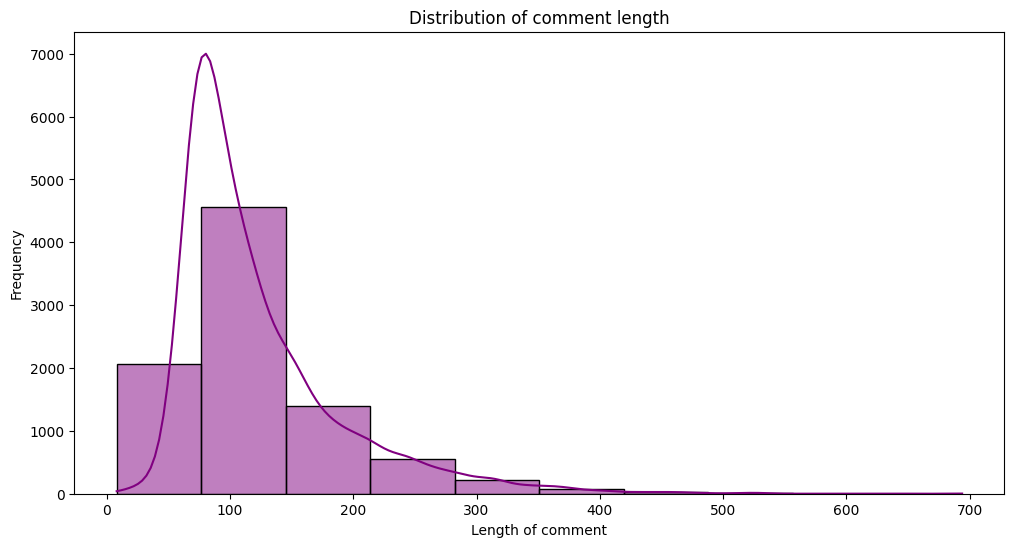

In [272]:
plt.figure(figsize=(12, 6))
sns.histplot(data=df_raw, x='Length', bins=10, kde=True, color='purple')
plt.title('Distribution of comment length')
plt.xlabel('Length of comment')
plt.ylabel('Frequency')
plt.show()

#### 3.9.1. Word Count: The number of words in each comment

In [273]:
word_count = df_raw['comment'][0].split()
print(f'Word count in a sample comment: {len(word_count)}')

Word count in a sample comment: 14


In [274]:
def word_count(review):
    review_list = review.split()
    return len(review_list)

In [275]:
df_raw['Word_count'] = df_raw['comment'].apply(word_count)
display(df_raw.head(5))

,comment,n_star,date_time,label,positive_count,neutral_count,negative_count,Length,Word_count
0,pin kém còn miễn chê mua 832019 tình_trạng pin...,5,2019-09-14,Neutral,1,0,1,66,14
1,sao gọi điện_thoại màn_hình chấm nhỏ nháy gần ...,3,2020-08-17,Negative,0,0,1,59,10
2,mọi người cập_nhật phần_mềm nó bớt tốn pin mìn...,3,2020-02-29,Neutral,0,2,1,78,17
3,mới mua sài 1 tháng thấy pin trâu sài bao mượt...,5,2020-06-04,Positive,2,0,1,154,35
4,xài tốt mượt pin trâu bạn độ sáng đủ nhân_viên...,5,2019-06-20,Positive,3,2,0,94,18


> Distribution of words in comments

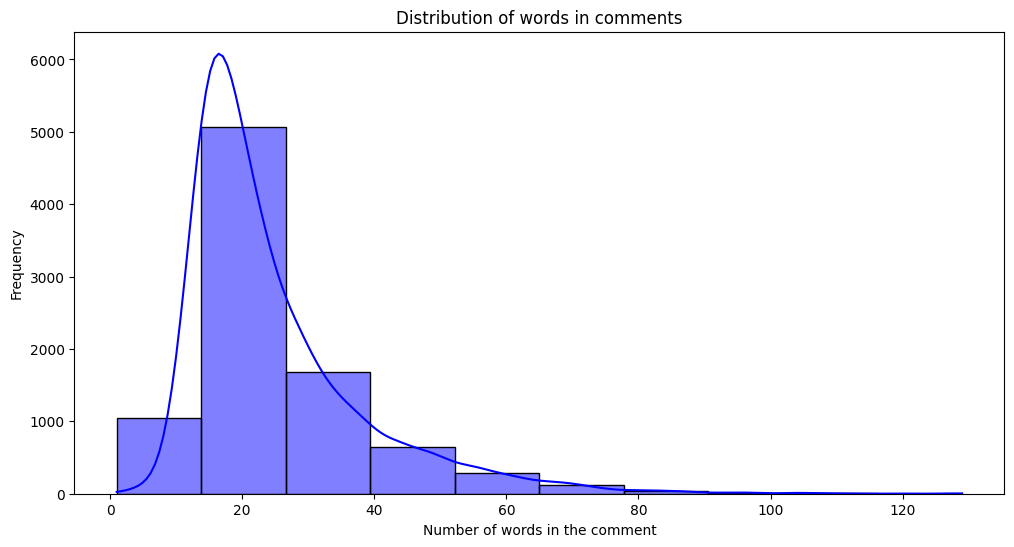

In [276]:
plt.figure(figsize=(12, 6))
sns.histplot(data=df_raw, x='Word_count', bins=10, kde=True, color='blue')
plt.title('Distribution of words in comments')
plt.xlabel('Number of words in the comment')
plt.ylabel('Frequency')
plt.show()

#### 3.9.2. Mean Word Length: The average length of the word

In [277]:
df_raw['mean_word_length'] = df_raw['comment'].map(lambda rev: np.mean([len(word) for word in rev.split()]))
display(df_raw.head(5))

,comment,n_star,date_time,label,positive_count,neutral_count,negative_count,Length,Word_count,mean_word_length
0,pin kém còn miễn chê mua 832019 tình_trạng pin...,5,2019-09-14,Neutral,1,0,1,66,14,3.785714
1,sao gọi điện_thoại màn_hình chấm nhỏ nháy gần ...,3,2020-08-17,Negative,0,0,1,59,10,5.000000
2,mọi người cập_nhật phần_mềm nó bớt tốn pin mìn...,3,2020-02-29,Neutral,0,2,1,78,17,3.647059
3,mới mua sài 1 tháng thấy pin trâu sài bao mượt...,5,2020-06-04,Positive,2,0,1,154,35,3.428571
4,xài tốt mượt pin trâu bạn độ sáng đủ nhân_viên...,5,2019-06-20,Positive,3,2,0,94,18,4.277778


> Distribution of average length of the word

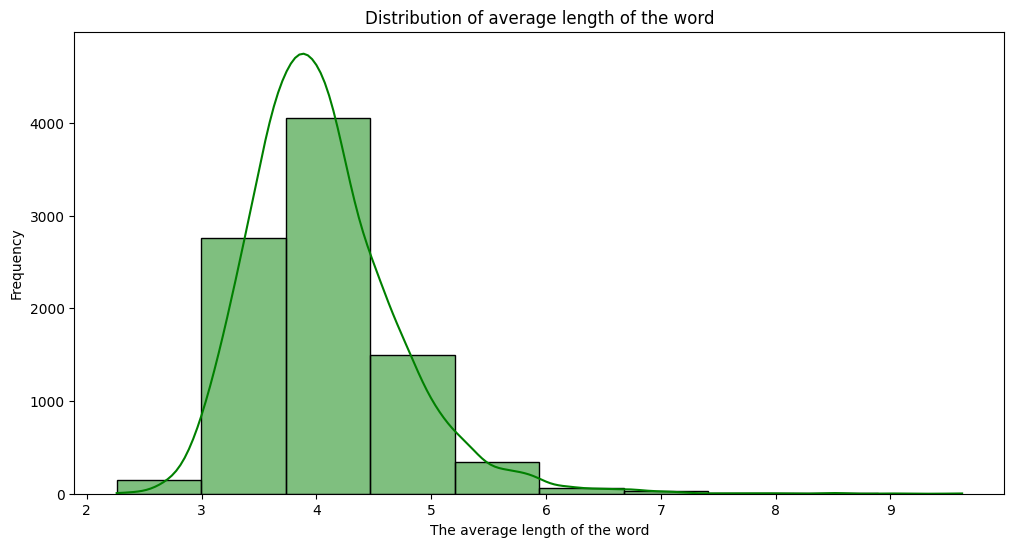

In [278]:
plt.figure(figsize=(12, 6))
sns.histplot(data=df_raw, x='mean_word_length', bins=10, kde=True, color='green')
plt.title('Distribution of average length of the word')
plt.xlabel('The average length of the word')
plt.ylabel('Frequency')
plt.show()


> Word Count and Mean Word Length by labels

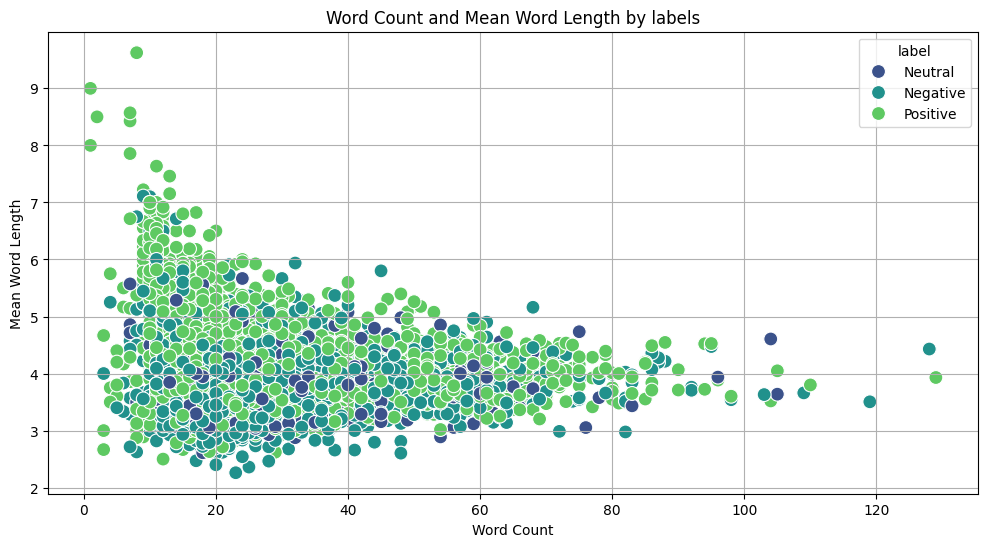

In [279]:
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df_raw, x='Word_count', y='mean_word_length', hue='label', palette='viridis', s=100)
plt.title('Word Count and Mean Word Length by labels')
plt.xlabel('Word Count')
plt.ylabel('Mean Word Length')
plt.grid(True)
plt.show()

#### 3.9.3. Mean Sentence Length: The average length of the sentence

In [280]:
mean_sent_len = np.mean(df_raw['Length'])
print(mean_sent_len)

123.12834344796583


In [281]:
def visualize(col, data):
    plt.figure(figsize=(12, 6))

    custom_palette = {'Positive': 'green', 'Neutral': 'blue', 'Negative': 'red'}

    plt.subplot(1, 2, 1)
    sns.boxplot(y=col, x='label', data=data, palette=custom_palette)
    plt.ylabel(col, labelpad=12.5)

    plt.subplot(1, 2, 2)
    sns.kdeplot(data=data, x=col, hue='label', fill=True, palette=custom_palette)
    plt.xlabel(col, labelpad=12.5)
    plt.ylabel('Density', labelpad=12.5)

    plt.show()

C:\Users\hghaa\AppData\Local\Temp\ipykernel_27204\4147405786.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=col, x='label', data=data, palette=custom_palette)


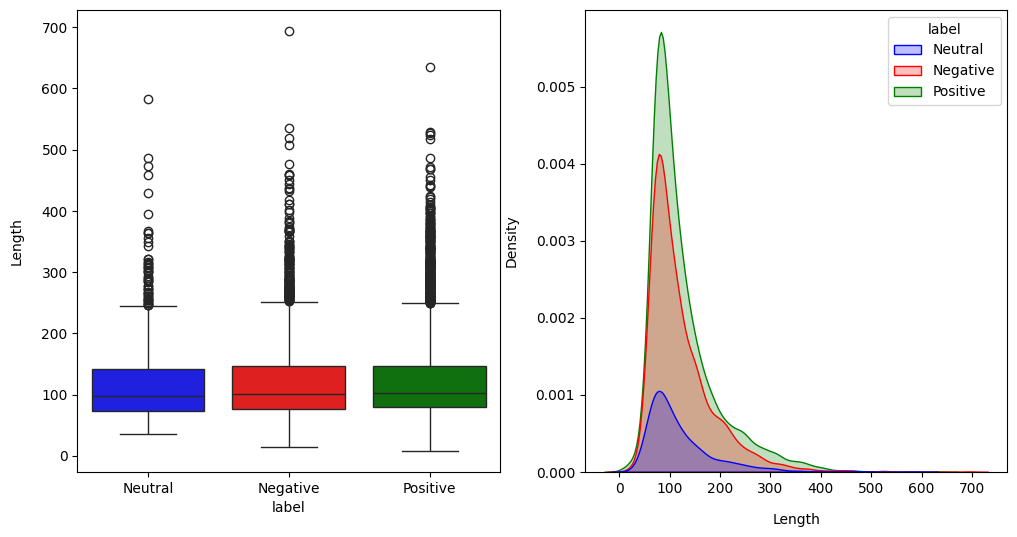

C:\Users\hghaa\AppData\Local\Temp\ipykernel_27204\4147405786.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=col, x='label', data=data, palette=custom_palette)


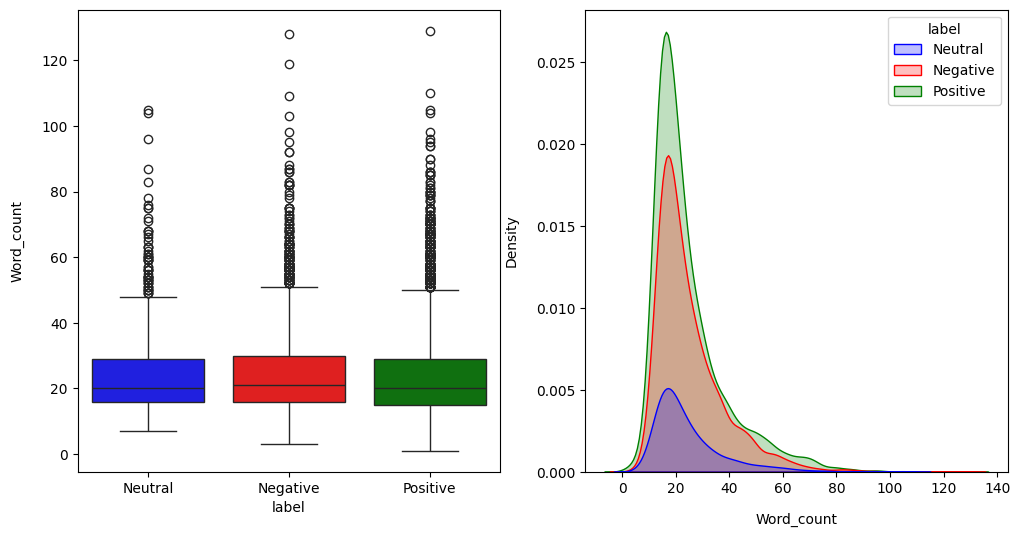

C:\Users\hghaa\AppData\Local\Temp\ipykernel_27204\4147405786.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=col, x='label', data=data, palette=custom_palette)


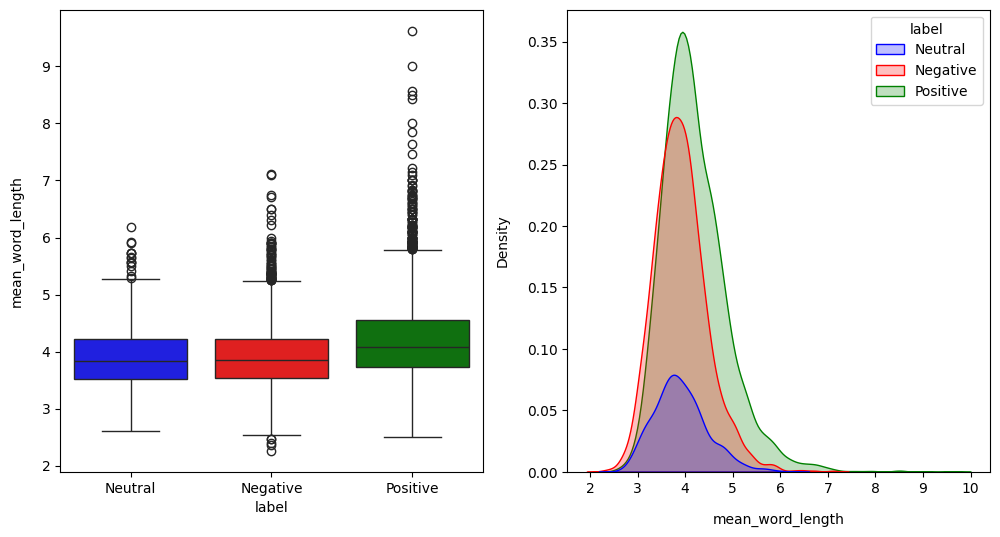

In [282]:
features = df_raw.columns.tolist()[7:]
for feature in features:
    visualize(feature, df_raw)

### 3.10. Correlation of sentence length and assessment status

In [283]:
positive_counts = (df_raw[df_raw['label'] == 'Positive'].groupby('Word_count').size())
negative_counts = (df_raw[df_raw['label'] == 'Negative'].groupby('Word_count').size())
neutral_counts = (df_raw[df_raw['label'] == 'Neutral'].groupby('Word_count').size())

In [284]:
bins = range(0, 141, 20)
positive_counts_bins = pd.cut(positive_counts.index, bins=bins, right=False)
negative_counts_bins = pd.cut(negative_counts.index, bins=bins, right=False)
neutral_counts_bins = pd.cut(neutral_counts.index, bins=bins, right=False)

In [285]:
positive_counts_segmented = positive_counts.groupby(positive_counts_bins).sum()
negative_counts_segmented = negative_counts.groupby(negative_counts_bins).sum()
neutral_counts_segmented = neutral_counts.groupby(neutral_counts_bins).sum()

C:\Users\hghaa\AppData\Local\Temp\ipykernel_27204\796927152.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  positive_counts_segmented = positive_counts.groupby(positive_counts_bins).sum()
C:\Users\hghaa\AppData\Local\Temp\ipykernel_27204\796927152.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  negative_counts_segmented = negative_counts.groupby(negative_counts_bins).sum()
C:\Users\hghaa\AppData\Local\Temp\ipykernel_27204\796927152.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior o

In [286]:
x_values = [interval.mid for interval in positive_counts_segmented.index]

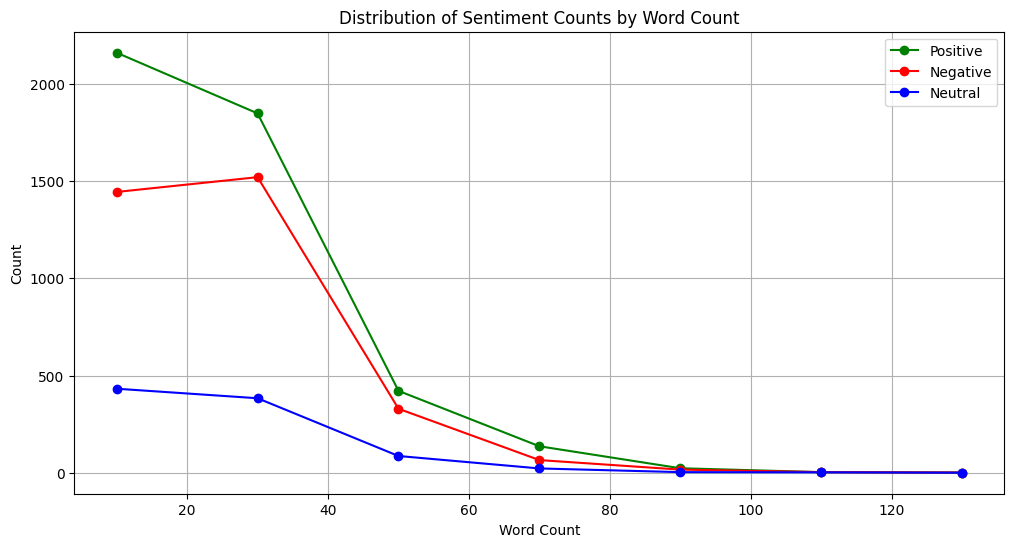

In [287]:
plt.figure(figsize=(12, 6))
plt.plot(x_values, positive_counts_segmented, label='Positive', marker='o', color='green', linestyle='-')
plt.plot(x_values, negative_counts_segmented, label='Negative', marker='o', color='red', linestyle='-')
plt.plot(x_values, neutral_counts_segmented, label='Neutral', marker='o', color='blue', linestyle='-')

plt.xlabel('Word Count')
plt.ylabel('Count')
plt.title('Distribution of Sentiment Counts by Word Count')

plt.legend()
plt.grid(True)

plt.show()

### 3.11. Pairplot for variables related to comments

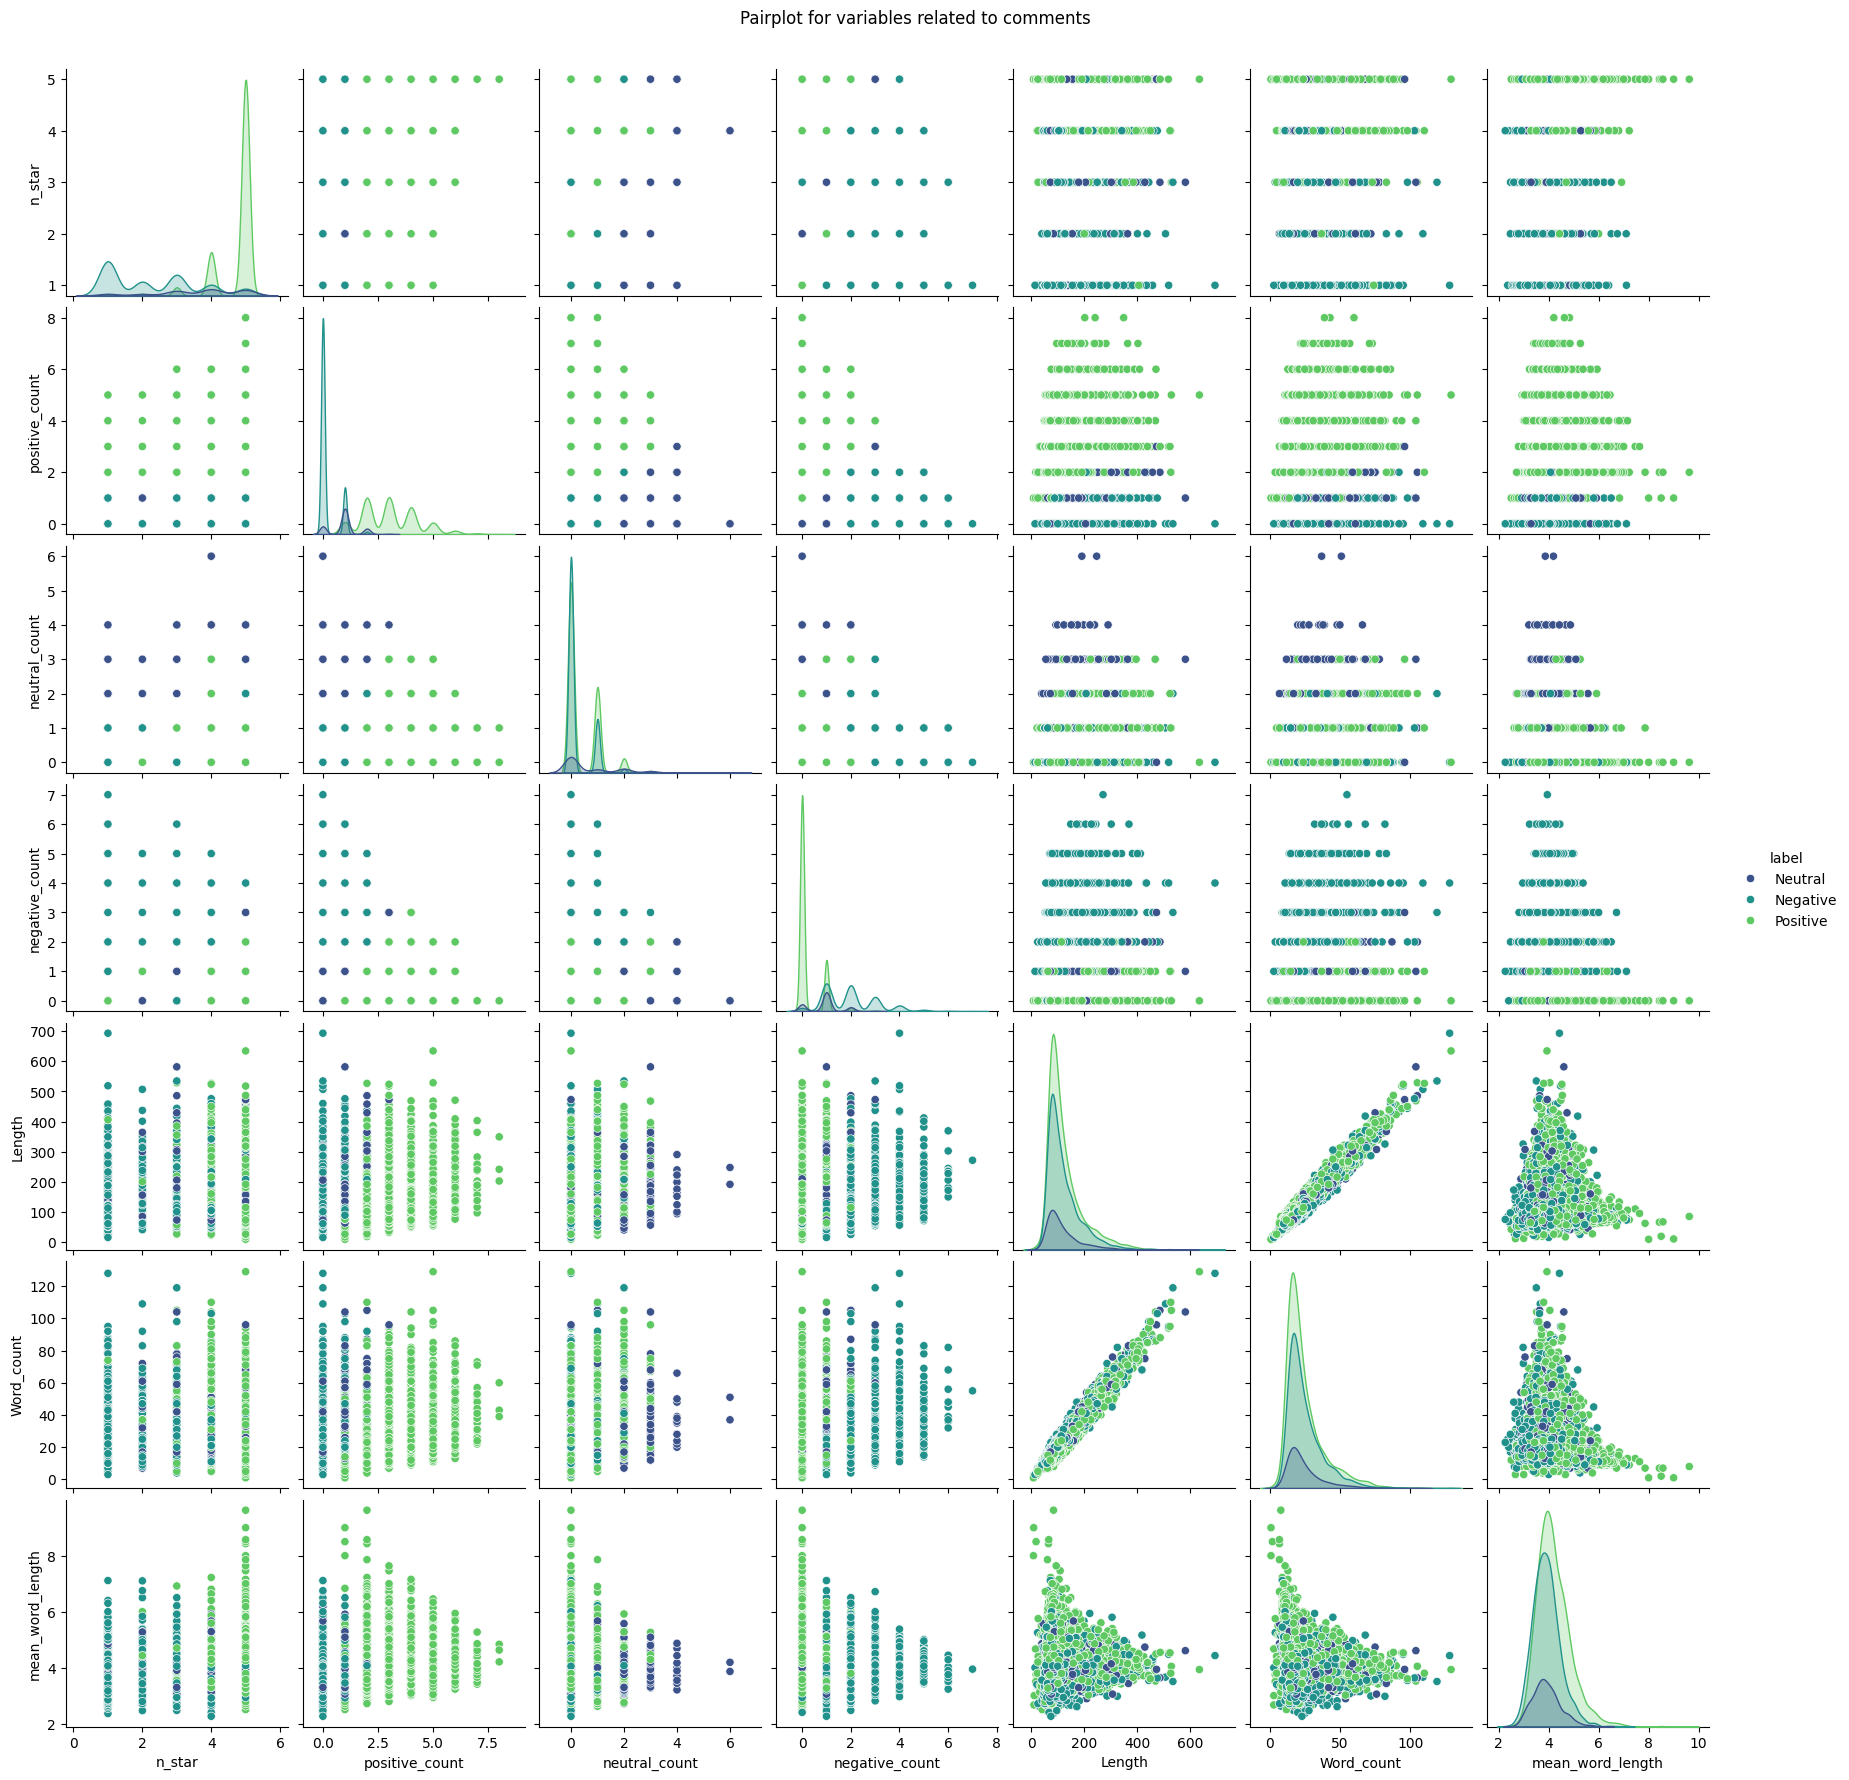

In [288]:
sns.pairplot(df_raw[['n_star', 'positive_count', 'neutral_count', 'negative_count', 'Length', 'Word_count', 'mean_word_length', 'label']], hue='label', palette='viridis')
plt.suptitle('Pairplot for variables related to comments', y=1.02)
plt.show()